<a href="https://colab.research.google.com/github/kibwale/nipe_macho/blob/main/Yolo11_NewData15th_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train YOLO11 Object Detection on a Custom Dataset

---

[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/ultralytics/ultralytics)

YOLO11 builds on the advancements introduced in YOLOv9 and YOLOv10 earlier this year, incorporating improved architectural designs, enhanced feature extraction techniques, and optimized training methods.

YOLO11m achieves a higher mean mAP score on the COCO dataset while using 22% fewer parameters than YOLOv8m, making it computationally lighter without sacrificing performance.

YOLOv11 is available in 5 different sizes, ranging from `2.6M` to `56.9M` parameters, and capable of achieving from `39.5` to `54.7` mAP on the COCO dataset.

## Setup

### Configure API keys

To fine-tune YOLO11, you need to provide your Roboflow API key. Follow these steps:

- Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑). Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

### Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [34]:
!nvidia-smi

Tue Jul 14 21:14:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [35]:
# ============================================================
# HOME VARIABLE — Run this once, all other cells depend on it
# ============================================================
# We explicitly set HOME to /content and change into it.
# Every file path in this notebook uses {HOME} as the root.
# Defining it once here prevents the "wrong directory" bugs.

import os
os.chdir("/content")
HOME = "/content"
print(f"✅ HOME = {HOME}")
print(f"   Working directory: {os.getcwd()}")

✅ HOME = /content
   Working directory: /content


## Install YOLO11 via Ultralytics

In [36]:
# ============================================================
# INSTALL PACKAGES
# ============================================================
# ultralytics  → YOLO11 framework (pinned to tested version)
# supervision  → visualisation utilities
# roboflow     → dataset management SDK
# kaggle       → dataset download CLI

%pip install "ultralytics<=8.3.40" supervision roboflow kaggle -q

# Disable Ultralytics telemetry
!yolo settings sync=False

# Verify the full software stack
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.0/112.6 GB disk)


In [37]:
# ============================================================
# CONFIGURE API KEYS
# ============================================================
# We pull all credentials from Colab Secrets (the 🔑 icon).
# They are NEVER hardcoded here. If you share this notebook,
# your keys remain private.
#
# Make sure you have added these three secrets in the sidebar:
#   ROBOFLOW_API_KEY  → from roboflow.com → Settings → API
#   KAGGLE_USERNAME   → your Kaggle username
#   KAGGLE_KEY        → the key value from your kaggle.json

from google.colab import userdata
import os, json

# --- Roboflow ---
ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
print("✅ Roboflow API key loaded")

# --- Kaggle ---
KAGGLE_USERNAME = userdata.get('KAGGLE_USERNAME')
KAGGLE_KEY      = userdata.get('KAGGLE_KEY')

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
!chmod 600 /root/.kaggle/kaggle.json

print(f"✅ Kaggle API key configured for user: {KAGGLE_USERNAME}")

✅ Roboflow API key loaded
✅ Kaggle API key configured for user: Mwangi kabacho


## Inference with model pre-trained on COCO dataset

### CLI

**NOTE:** CLI requires no customization or Python code. You can simply run all tasks from the terminal with the yolo command.

**NOTE:** Result annotated image got saved in `{HOME}/runs/detect/predict/`. Let's display it.

In [38]:
# ============================================================
# PRE-TRAINING SANITY CHECK
# ============================================================
# Before touching our dataset, we verify YOLO11 works correctly
# in this environment. We run inference on a sample image using
# pre-trained COCO weights (knows 80 common objects).
#
# This is NOT training — it's a 10-second smoke test.
# If this fails, something is wrong with the installation.

import os
os.chdir(HOME)  # ← THIS is what was missing before. Forces YOLO
                # to save results relative to /content

!yolo task=detect mode=predict \
      model=yolo11n.pt \
      conf=0.25 \
      source='https://media.roboflow.com/notebooks/examples/dog.jpeg' \
      save=True

# Display the result
# The file is at HOME/runs/detect/predict/dog.jpeg
from IPython.display import Image as IPyImage
import glob

# Find the saved image dynamically (avoids hardcoding predict vs predict2 etc)
predict_dirs = glob.glob(f'{HOME}/runs/detect/predict*/')
latest = max(predict_dirs, key=os.path.getmtime)
saved_image = os.path.join(latest, 'dog.jpeg')

if os.path.exists(saved_image):
    print(f"✅ Inference successful. Result saved at: {saved_image}")
    IPyImage(filename=saved_image, width=600)
else:
    print(f"⚠️  Could not find result. Contents of {latest}:")
    print(os.listdir(latest))

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 238 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

Found https://media.roboflow.com/notebooks/examples/dog.jpeg locally at dog.jpeg
image 1/1 /content/dog.jpeg: 640x384 2 persons, 1 car, 1 dog, 1 handbag, 51.4ms
Speed: 2.4ms preprocess, 51.4ms inference, 79.4ms postprocess per image at shape (1, 3, 640, 384)
Results saved to runs/detect/predict2
💡 Learn more at https://docs.ultralytics.com/modes/predict
⚠️  Could not find result. Contents of /content/runs/detect/predict2/:
['dog.jpg']


**Dataset Preparation**

Download Dataset

In [39]:
# ============================================================
# DOWNLOAD POTHOLE DATASET FROM KAGGLE
# ============================================================
# Dataset: "Potholes or Cracks on Road" by Datacluster Labs
# Paper:   Shakhovska et al., 2024 — mAP@0.50 = 93.75%
# Format:  Pascal VOC (.xml annotations)
# Size:    209 images, 195 annotated, 14 background
#
# THE KEY FIX: We check if the zip already exists before
# downloading. This means "Run All" won't re-download 903MB
# every single time — it only downloads once per Colab session.

import os

RAW_DIR  = f"{HOME}/datasets/pothole-raw"
ZIP_NAME = "potholes-or-cracks-on-road-image-dataset.zip"
ZIP_PATH = os.path.join(RAW_DIR, ZIP_NAME)

os.makedirs(RAW_DIR, exist_ok=True)
os.chdir(RAW_DIR)

if os.path.exists(ZIP_PATH):
    # File already downloaded this session — skip the 903MB download
    print(f"✅ Dataset zip already exists ({os.path.getsize(ZIP_PATH)/1e6:.1f} MB)")
    print(f"   Skipping download. Delete the zip to force a fresh download.")
else:
    print("⬇️  Downloading dataset from Kaggle (903MB — one time only)...")
    !kaggle datasets download \
        -d dataclusterlabs/potholes-or-cracks-on-road-image-dataset
    print(f"\n✅ Download complete")

!ls -lh

⬇️  Downloading dataset from Kaggle (903MB — one time only)...
Dataset URL: https://www.kaggle.com/datasets/dataclusterlabs/potholes-or-cracks-on-road-image-dataset
License(s): CC0-1.0
100% 902M/902M [00:48<00:00, 19.6MB/s]


✅ Download complete
total 903M
-rw-r--r-- 1 root root 903M Sep 26  2022 potholes-or-cracks-on-road-image-dataset.zip


** Unzip Dataset**

In [40]:
# ============================================================
# UNZIP DATASET
# ============================================================
# Same principle — check before unzipping to avoid repeating
# work when you click Run All in the same session.

import os

RAW_DIR      = f"{HOME}/datasets/pothole-raw"
DATASET_DIR  = os.path.join(RAW_DIR, "dataset")

if os.path.exists(DATASET_DIR):
    print(f"✅ Dataset already unzipped at: {DATASET_DIR}")
else:
    print("📦 Unzipping...")
    os.chdir(RAW_DIR)
    !unzip -q potholes-or-cracks-on-road-image-dataset.zip
    print("✅ Unzipped successfully")

# Safely find the batch folder (handles unicode in folder name)
subfolders = [
    os.path.join(DATASET_DIR, d)
    for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
]

DATASET_FOLDER = subfolders[0]

# Count files
all_files = os.listdir(DATASET_FOLDER)
jpgs = [f for f in all_files if f.lower().endswith('.jpg')]
xmls = [f for f in all_files if f.lower().endswith('.xml')]

print(f"\n📁 Dataset folder: {DATASET_FOLDER}")
print(f"   🖼️  Images (.jpg):      {len(jpgs)}")
print(f"   🏷️  Annotations (.xml): {len(xmls)}")
print(f"   📄 Background images:   {len(jpgs) - len(xmls)}")

📦 Unzipping...
✅ Unzipped successfully

📁 Dataset folder: /content/datasets/pothole-raw/dataset/potholes bat├зh 1
   🖼️  Images (.jpg):      209
   🏷️  Annotations (.xml): 195
   📄 Background images:   14


**Inspect One Annotation File**

In [41]:
# ============================================================
# INSPECT ANNOTATION FORMAT
# ============================================================
# Before uploading, we verify the XML structure is valid
# and see exactly what class names the annotators used.
# Class names in the XML become your model's output labels.

import xml.etree.ElementTree as ET
import os

xml_files = sorted([f for f in os.listdir(DATASET_FOLDER) if f.endswith('.xml')])
sample_path = os.path.join(DATASET_FOLDER, xml_files[0])

tree = ET.parse(sample_path)
root = tree.getroot()

print(f"Sample file: {xml_files[0]}")
print("=" * 50)
print(f"Image:  {root.find('filename').text}")
print(f"Width:  {root.find('size/width').text}px")
print(f"Height: {root.find('size/height').text}px")

for i, obj in enumerate(root.findall('object')):
    bbox = obj.find('bndbox')
    print(f"\nObject {i+1}:")
    print(f"  Class: {obj.find('name').text}")
    print(f"  Box:   xmin={bbox.find('xmin').text}, "
          f"ymin={bbox.find('ymin').text}, "
          f"xmax={bbox.find('xmax').text}, "
          f"ymax={bbox.find('ymax').text}")

# Scan ALL xml files for every class name used
all_classes = set()
for xml_file in xml_files:
    tree = ET.parse(os.path.join(DATASET_FOLDER, xml_file))
    for obj in tree.getroot().findall('object'):
        all_classes.add(obj.find('name').text)

print("\n" + "=" * 50)
print("ALL CLASSES ACROSS ENTIRE DATASET:")
for cls in sorted(all_classes):
    print(f"  → '{cls}'")
print(f"\nTotal classes: {len(all_classes)}")

Sample file: 20220815_16_11_41_045_000_jT85iRGUsKVY0iTx40U5DTQKCYf2_F_3264_2448 (1).xml
Image:  20220815_16_11_41_045_000_jT85iRGUsKVY0iTx40U5DTQKCYf2_F_3264_2448 (1).jpg
Width:  2448px
Height: 3264px

Object 1:
  Class: potholes
  Box:   xmin=1273, ymin=1071, xmax=1531, ymax=1239

Object 2:
  Class: potholes
  Box:   xmin=1073, ymin=1250, xmax=1242, ymax=1371

ALL CLASSES ACROSS ENTIRE DATASET:
  → 'potholes'
  → 'w'

Total classes: 2


**Upload to Roboflow**

In [46]:
from roboflow import Roboflow

rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# This lists every workspace your API key has access to
import requests
resp = requests.get(f"https://api.roboflow.com/?api_key={ROBOFLOW_API_KEY}")
print(resp.json())

{'welcome': 'Welcome to the Roboflow API.', 'instructions': 'You are successfully authenticated.', 'docs': 'https://docs.roboflow.com', 'workspace': 'mwangis-workspace', 'workspaceId': 'PMfBzLAXusU4MOQIMuPOkyukDXg1'}


In [47]:
import requests

resp = requests.get(f"https://api.roboflow.com/mwangis-workspace?api_key={ROBOFLOW_API_KEY}")
data = resp.json()

print("Projects in this workspace:")
for p in data.get("workspace", {}).get("projects", []):
    print(f"  → {p}")

Projects in this workspace:
  → {'id': 'mwangis-workspace/pothole-detection-cito3', 'type': 'object-detection', 'name': 'pothole-detection', 'created': 1784059056.105, 'updated': 1784059056.105, 'images': 0, 'unannotated': 0, 'annotation': 'pothole-detection', 'versions': 0, 'public': True, 'multilabel': False, 'license': 'CC BY 4.0', 'splits': {'train': 0, 'valid': 0, 'test': 0}, 'colors': {}, 'classes': {}, 'icon': None, 'preprocessing': {'auto-orient': True, 'resize': {'format': 'Stretch to', 'width': 512, 'height': 512}}, 'augmentation': {}}


In [49]:
# ============================================================
# UPLOAD TO ROBOFLOW
# ============================================================
from roboflow import Roboflow
import os

rf      = Roboflow(api_key=ROBOFLOW_API_KEY)
ws      = rf.workspace("mwangis-workspace")               # ← confirmed correct
project = ws.project("pothole-detection-cito3")            # ← confirmed correct

print(f"✅ Connected: {project.name}")
print(f"   Uploading {len([f for f in os.listdir(DATASET_FOLDER) if f.endswith('.jpg')])} images...\n")

uploaded, skipped, failed = 0, 0, 0
jpg_files = sorted([f for f in os.listdir(DATASET_FOLDER) if f.endswith('.jpg')])

for i, jpg_file in enumerate(jpg_files):
    img_path = os.path.join(DATASET_FOLDER, jpg_file)
    xml_path = os.path.join(DATASET_FOLDER, jpg_file.replace('.jpg', '.xml'))

    try:
        if os.path.exists(xml_path):
            project.upload(
                image_path      = img_path,
                annotation_path = xml_path,
                split           = "train",
                batch_name      = "datacluster-batch-1"
            )
            uploaded += 1
        else:
            project.upload(
                image_path = img_path,
                split      = "train",
                batch_name = "datacluster-batch-1"
            )
            skipped += 1
    except Exception as e:
        failed += 1
        print(f"  ⚠️  {jpg_file}: {str(e)[:80]}")

    if (i + 1) % 25 == 0:
        print(f"  [{i+1}/{len(jpg_files)}] uploaded:{uploaded} background:{skipped} failed:{failed}")

print(f"\n{'='*45}")
print(f"✅ UPLOAD COMPLETE")
print(f"   With annotations : {uploaded}")
print(f"   Background images: {skipped}")
print(f"   Failed           : {failed}")
print(f"\n→ Go to roboflow.com/mwangis-workspace/pothole-detection-cito3 to verify")

loading Roboflow workspace...
loading Roboflow project...
✅ Connected: pothole-detection
   Uploading 209 images...

  [25/209] uploaded:25 background:0 failed:0
  [50/209] uploaded:47 background:3 failed:0
  [75/209] uploaded:65 background:10 failed:0
  [100/209] uploaded:88 background:12 failed:0
  [125/209] uploaded:113 background:12 failed:0
  [150/209] uploaded:138 background:12 failed:0
  [175/209] uploaded:163 background:12 failed:0
  [200/209] uploaded:188 background:12 failed:0

✅ UPLOAD COMPLETE
   With annotations : 195
   Background images: 14
   Failed           : 0

→ Go to roboflow.com/mwangis-workspace/pothole-detection-cito3 to verify


In [50]:
version = project.generate_version(
    settings={
        "preprocessing": {
            "auto-orient": True,
            "resize": {"width": 640, "height": 640, "format": "Stretch to"}
        },
        "augmentation": {
            "flip": {"horizontal": True, "vertical": False},
            "brightness": {"brighten": 15, "darken": 15}
        },
        "split": {"train": 70, "valid": 20, "test": 10}
    }
)
print(f"✅ Version {version.version} generated")

RuntimeError: {'message': 'brightness requires boolean brighten and darken values'}

**Generate Dataset Version + Download in YOLO Format**

In [55]:
from roboflow import Roboflow
import os

rf      = Roboflow(api_key=ROBOFLOW_API_KEY)
ws      = rf.workspace("nipemacho")
project = ws.project("chepalungu")  # ← fixed

os.makedirs(f"{HOME}/datasets", exist_ok=True)
os.chdir(f"{HOME}/datasets")

version = project.version(1)   # only works after a version exists (Option A or B above)
dataset = version.download("yolov11")

print(f"\n✅ Dataset downloaded to: {dataset.location}")
for split in ['train', 'valid', 'test']:
    img = os.path.join(dataset.location, split, 'images')
    lbl = os.path.join(dataset.location, split, 'labels')
    if os.path.exists(img):
        print(f"   {split:>5}: {len(os.listdir(img))} images | {len(os.listdir(lbl))} labels")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to chepalungu-1 in yolov11:: 100%|██████████| 527/527 [00:00<00:00, 8250.00it/s]


✅ Dataset downloaded to: /content/datasets/chepalungu-1
   train: 183 images | 183 labels
   valid: 52 images | 52 labels
    test: 26 images | 26 labels


In [52]:
# ============================================================
# GENERATE DATASET VERSION AND DOWNLOAD
# ============================================================
# "Generating a version" tells Roboflow to:
#   1. Split into train(70%) / valid(20%) / test(10%)
#   2. Resize all images to 640×640
#   3. Apply augmentation (multiplies dataset ~3x)
#   4. Convert to YOLO .txt label format
#   5. Assign a version number for reproducibility
#
# Then we download it back into Colab ready for training.

from roboflow import Roboflow
import os

# Re-authenticate (safe to run again)
rf      = Roboflow(api_key=ROBOFLOW_API_KEY)
ws      = rf.workspace("nipemacho-workspace")
project = ws.project("chepalungu")

# Download version 1 (after you've generated it on roboflow.com)
# If you haven't generated it yet via the website, do that first:
# roboflow.com → your project → Versions → Generate New Version
# Settings: resize 640x640, flip horizontal, brightness ±15%

os.makedirs(f"{HOME}/datasets", exist_ok=True)
os.chdir(f"{HOME}/datasets")

version = project.version(1)           # ← version number from Roboflow
dataset = version.download("yolov11")

# Verify structure
print(f"\n✅ Dataset downloaded to: {dataset.location}")
for split in ['train', 'valid', 'test']:
    img = os.path.join(dataset.location, split, 'images')
    lbl = os.path.join(dataset.location, split, 'labels')
    if os.path.exists(img):
        print(f"   {split:>5}: {len(os.listdir(img))} images | {len(os.listdir(lbl))} labels")

print("\n=== data.yaml ===")
with open(os.path.join(dataset.location, 'data.yaml')) as f:
    print(f.read())

loading Roboflow workspace...
loading Roboflow project...

✅ Dataset downloaded to: /content/datasets/pothole-detection-1
   train: 112 images | 112 labels

=== data.yaml ===
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['potholes', 'w']

roboflow:
  workspace: mwangis-workspace
  project: pothole-detection-cito3
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/mwangis-workspace/pothole-detection-cito3/dataset/1


**Training**

Train the Model

In [56]:
# ============================================================
# TRAIN YOLO11 ON YOUR POTHOLE DATASET
# ============================================================
# model=yolo11s.pt  → Small variant. Good balance of speed
#                     and accuracy for 200-image datasets.
#                     Starts with ImageNet pretrained weights
#                     then fine-tunes on your potholes.
#
# epochs=50         → 50 full passes through the training data.
#                     For 200 images this is appropriate —
#                     enough to converge without overfitting.
#
# imgsz=640         → Standard YOLO input resolution.
#
# patience=20       → Stop early if no improvement for 20 epochs.
#                     Prevents wasting time on a converged model.
#
# plots=True        → Save confusion matrix, loss curves, PR curves.

os.chdir(HOME)

!yolo task=detect mode=train \
      model=yolo11s.pt \
      data={dataset.location}/data.yaml \
      epochs=50 \
      imgsz=640 \
      patience=20 \
      plots=True \
      project={HOME}/runs/detect \
      name=pothole_v1

print("\n✅ Training complete!")
print(f"   Best weights: {HOME}/runs/detect/pothole_v1/weights/best.pt")

New https://pypi.org/project/ultralytics/8.4.95 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/content/datasets/chepalungu-1/data.yaml, epochs=50, time=None, patience=20, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=/content/runs/detect, name=pothole_v12, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, 

**Evaluate and Visualise Results**


View Training Curves

Training files created:
args.yaml					     train_batch0.jpg
confusion_matrix_normalized.png			     train_batch1.jpg
confusion_matrix.png				     train_batch2.jpg
events.out.tfevents.1784069623.934fb3ad230b.40090.0  train_batch480.jpg
F1_curve.png					     train_batch481.jpg
labels_correlogram.jpg				     train_batch482.jpg
labels.jpg					     val_batch0_labels.jpg
P_curve.png					     val_batch0_pred.jpg
PR_curve.png					     val_batch1_labels.jpg
R_curve.png					     val_batch1_pred.jpg
results.csv					     weights
results.png

--- Results (Loss + mAP curves) ---


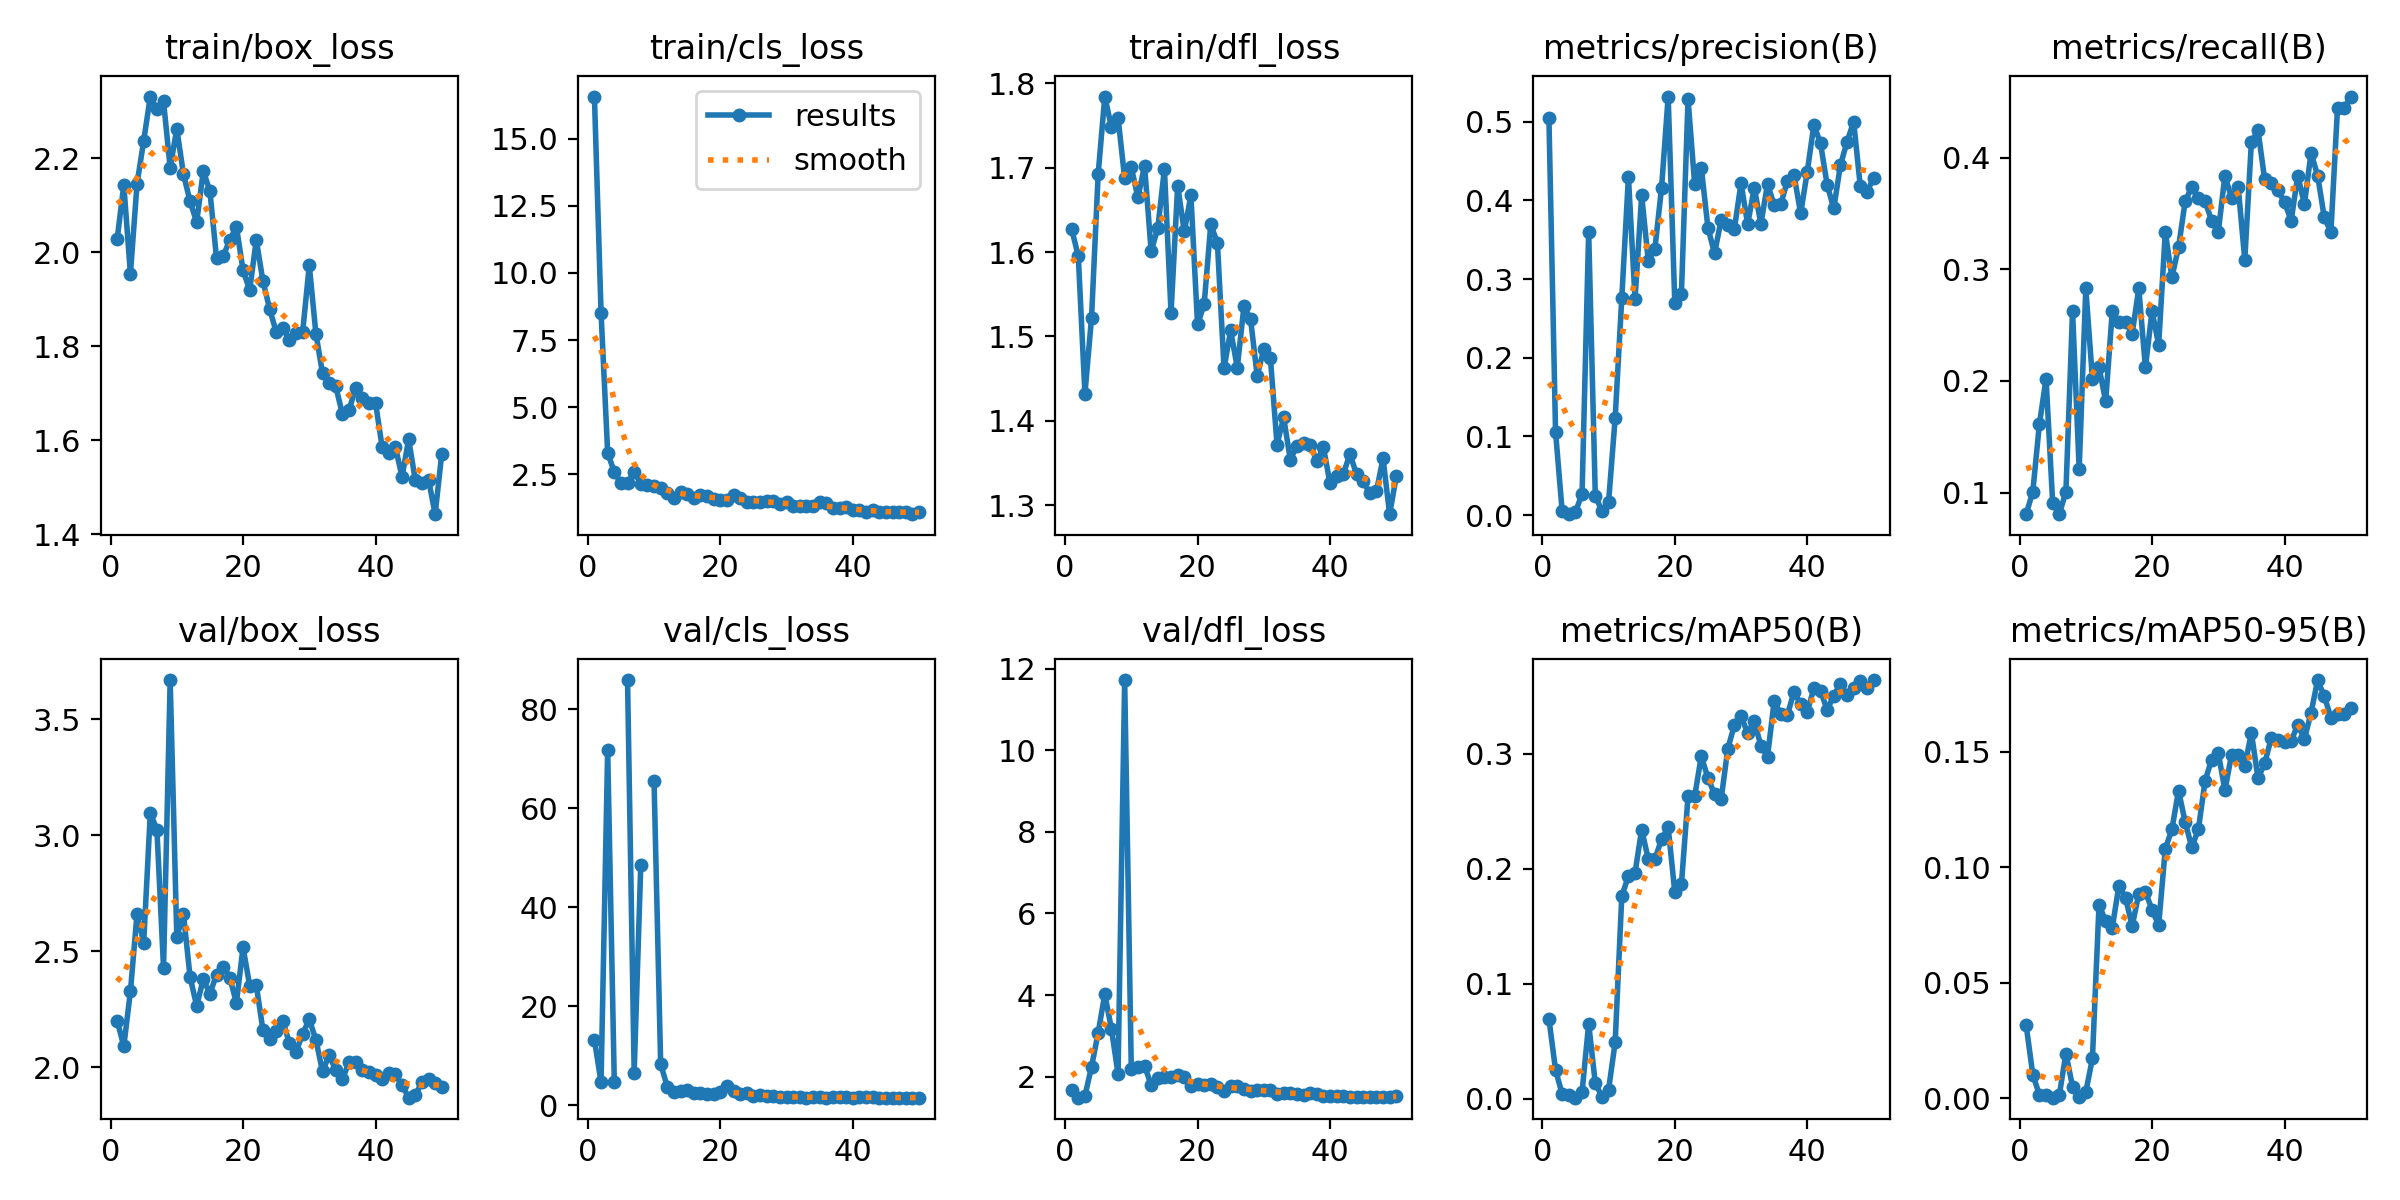

In [58]:
from IPython.display import Image as IPyImage

TRAIN_DIR = f"{HOME}/runs/detect/pothole_v12"   # ← fixed folder name

print("Training files created:")
!ls {TRAIN_DIR}

print("\n--- Results (Loss + mAP curves) ---")
IPyImage(filename=f'{TRAIN_DIR}/results.png', width=800)

--- Confusion Matrix ---


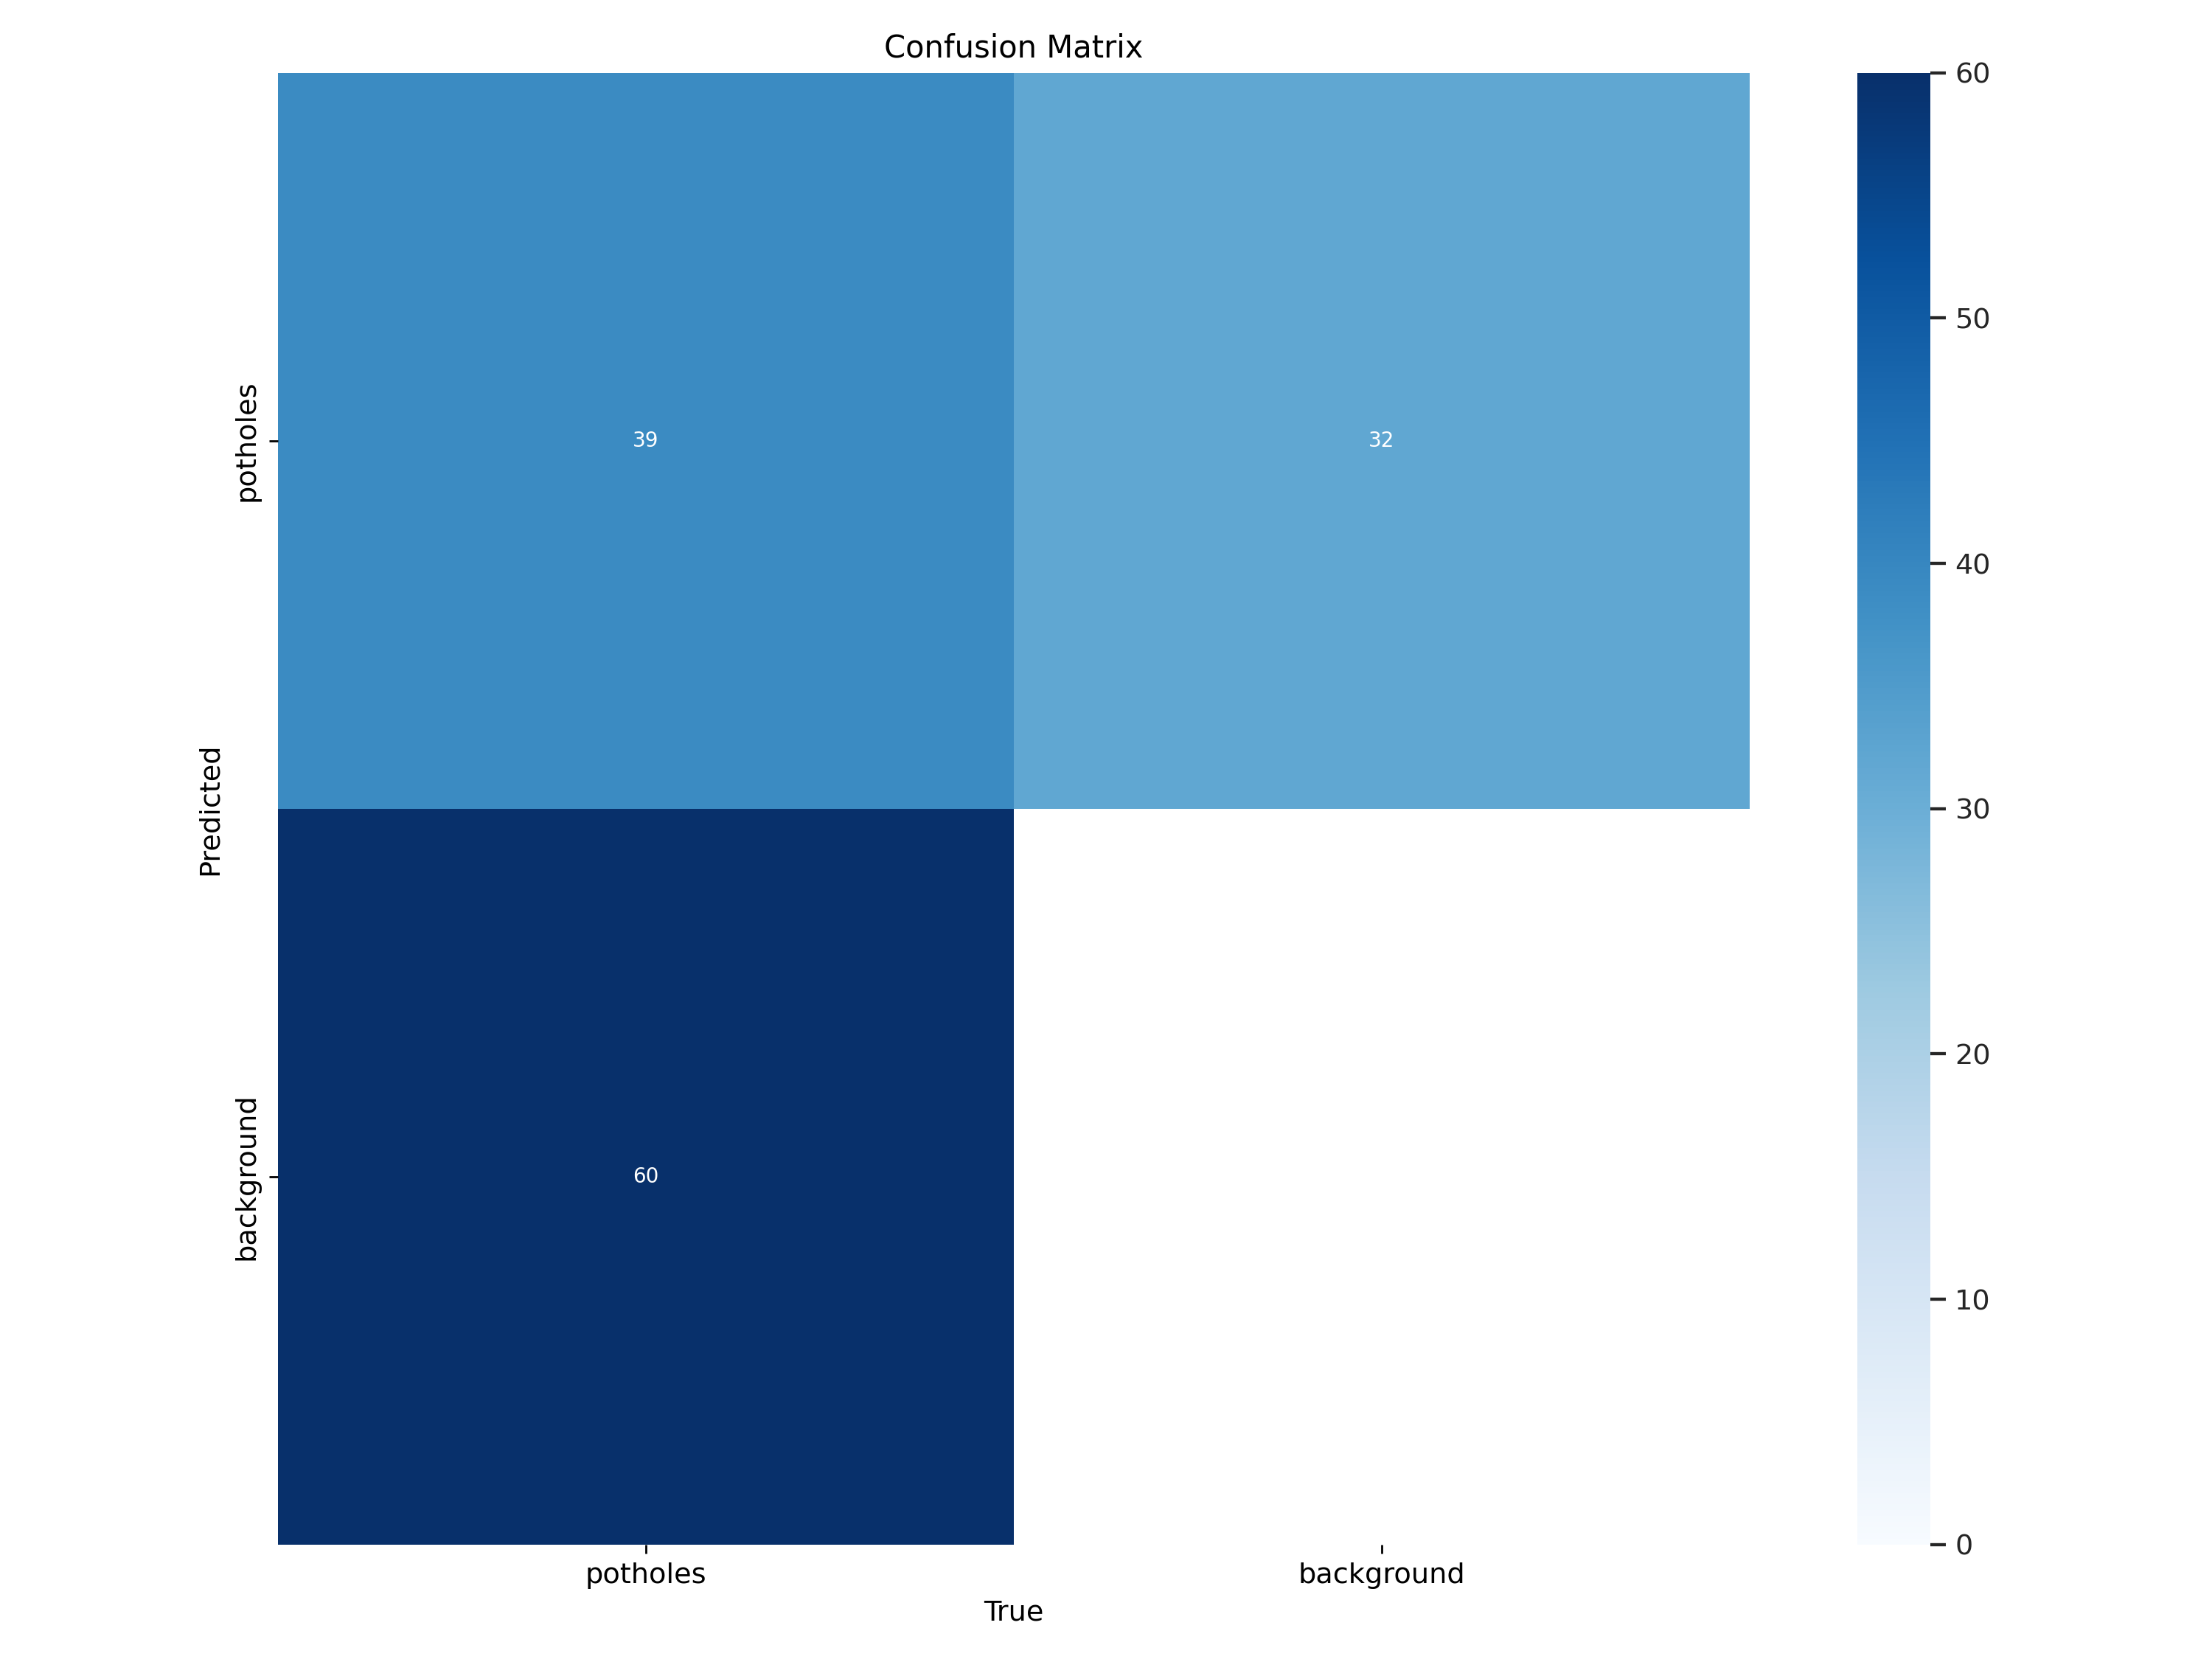

In [59]:
print("--- Confusion Matrix ---")
IPyImage(filename=f'{TRAIN_DIR}/confusion_matrix.png', width=600)

--- Sample Validation Predictions ---


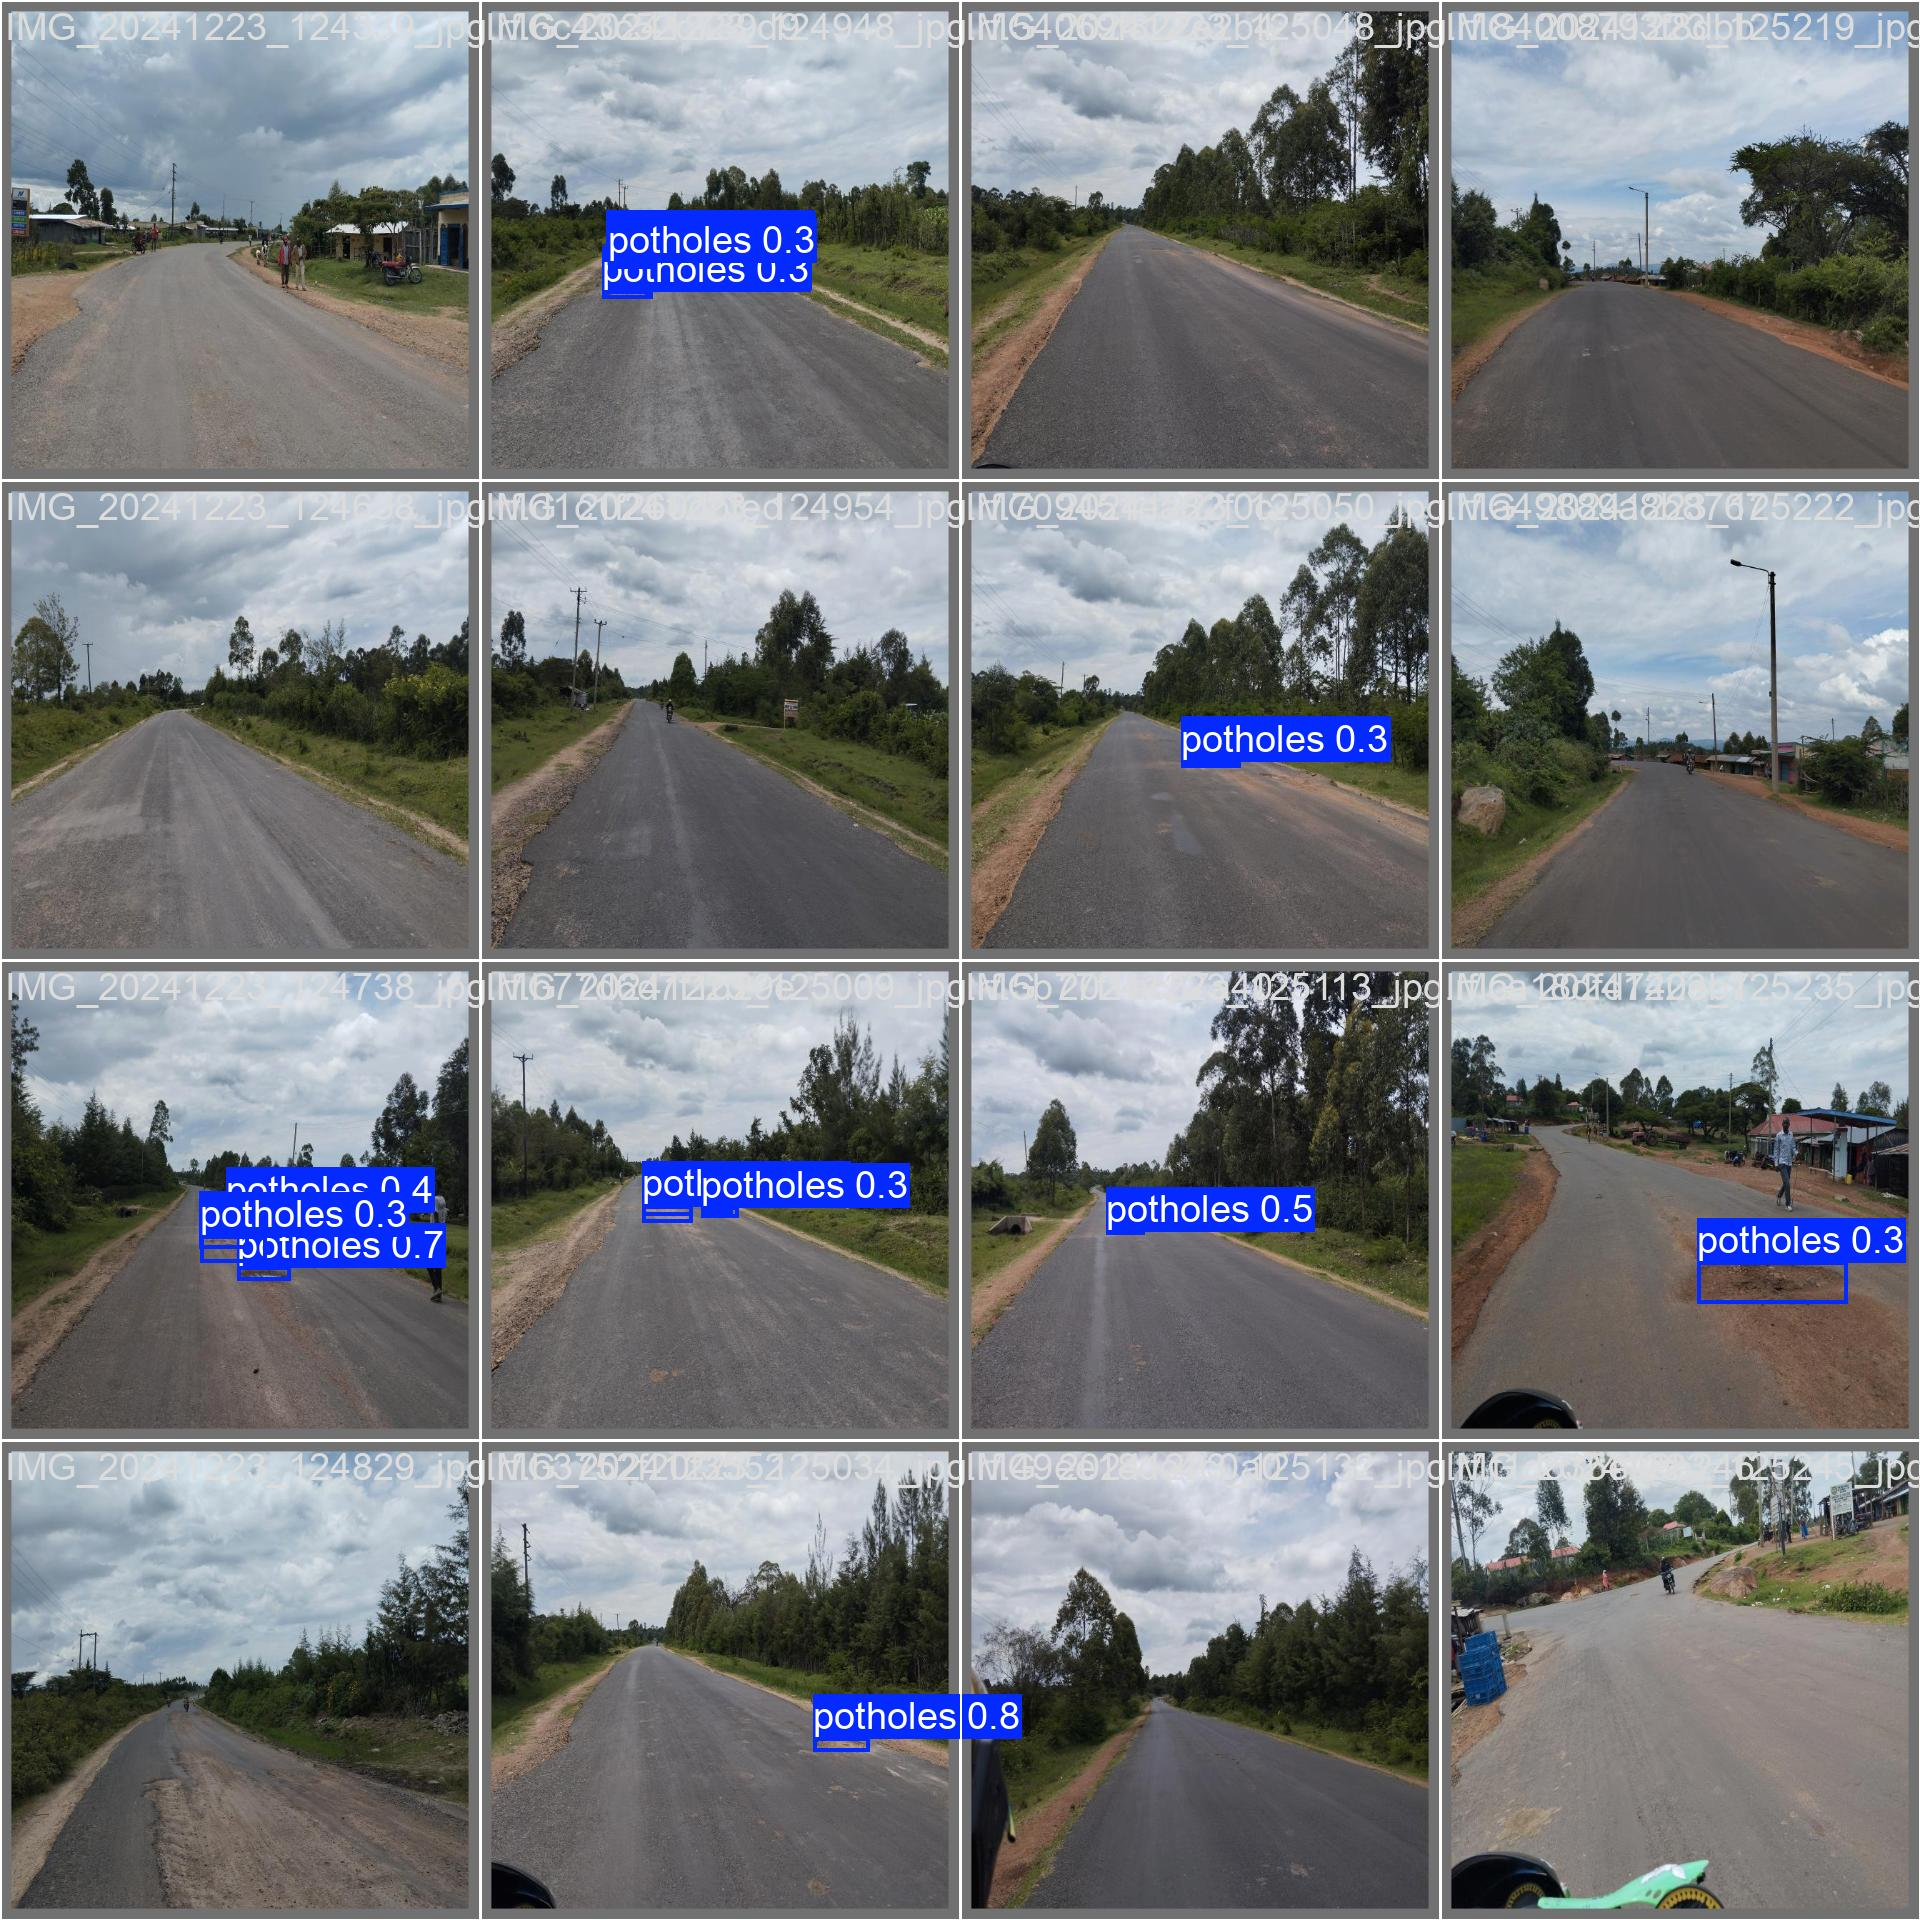

In [60]:
print("--- Sample Validation Predictions ---")
IPyImage(filename=f'{TRAIN_DIR}/val_batch0_pred.jpg', width=600)

In [57]:
# ============================================================
# VIEW TRAINING RESULTS
# ============================================================
# After training, YOLO saves these files in the run folder:
#   results.png         → loss curves + mAP over epochs
#   confusion_matrix.png → what the model got right/wrong
#   val_batch0_pred.jpg → sample validation predictions

from IPython.display import Image as IPyImage

TRAIN_DIR = f"{HOME}/runs/detect/pothole_v12"

print("Training files created:")
!ls {TRAIN_DIR}

print("\n--- Results (Loss + mAP curves) ---")
IPyImage(filename=f'{TRAIN_DIR}/results.png', width=800)

print("--- Confusion Matrix ---")
IPyImage(filename=f'{TRAIN_DIR}/confusion_matrix.png', width=600)

print("--- Sample Validation Predictions ---")
IPyImage(filename=f'{TRAIN_DIR}/val_batch0_pred.jpg', width=600)

Training files created:
args.yaml  weights

--- Results (Loss + mAP curves) ---


FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/detect/pothole_v1/results.png'

In [ ]:
print("--- Confusion Matrix ---")
IPyImage(filename=f'{TRAIN_DIR}/confusion_matrix.png', width=600)

In [ ]:
print("--- Sample Validation Predictions ---")
IPyImage(filename=f'{TRAIN_DIR}/val_batch0_pred.jpg', width=600)

**Validate on Test Set**

In [ ]:
# ============================================================
# VALIDATE MODEL ON HELD-OUT TEST SET
# ============================================================
# This runs your best trained model against the test images
# it has NEVER seen during training or validation.
# This is your true accuracy number.

!yolo task=detect mode=val \
      model={HOME}/runs/detect/pothole_v1/weights/best.pt \
      data={dataset.location}/data.yaml \
      plots=True

**Run Inference on Test Images**

In [ ]:
# ============================================================
# INFERENCE ON TEST IMAGES
# ============================================================
# Run your trained pothole detector on the test set
# and display 3 random results with bounding boxes.

os.chdir(HOME)

!yolo task=detect mode=predict \
      model={HOME}/runs/detect/pothole_v1/weights/best.pt \
      conf=0.25 \
      source={dataset.location}/test/images \
      save=True

# Display 3 results
import glob
from IPython.display import display

predict_dirs = glob.glob(f'{HOME}/runs/detect/predict*/')
latest = max(predict_dirs, key=os.path.getmtime)
result_images = glob.glob(f'{latest}/*.jpg')[:3]

print(f"Showing {len(result_images)} detection results:\n")
for img_path in result_images:
    print(os.path.basename(img_path))
    display(IPyImage(filename=img_path, width=600))
    print()

### SDK

**NOTE:** YOLO's Python interface allows for seamless integration into your Python projects, making it easy to load, run, and process the model's output.

In [ ]:
from ultralytics import YOLO
from PIL import Image
import requests

model = YOLO('yolo11n.pt')
image = Image.open(requests.get('https://media.roboflow.com/notebooks/examples/dog.jpeg', stream=True).raw)
result = model.predict(image, conf=0.25)[0]

In [ ]:
!pip install -q roboflow

In [ ]:
# ============================================================
# CELL A: Install Kaggle API and configure authentication
# ============================================================
# We install the Kaggle Python package which gives us the
# kaggle CLI command for downloading datasets programmatically.
# This is far faster than browser downloads, especially for
# large datasets, because Colab uses Google's data center
# internet connection (typically 50-100 MB/s).

!pip install kaggle -q

# Now we retrieve our Kaggle credentials from Colab Secrets.
# We stored them there (not hardcoded here) so that if you
# ever share this notebook, your credentials are never visible.
from google.colab import userdata
import os
import json

KAGGLE_USERNAME = userdata.get('KAGGLE_USERNAME')
KAGGLE_KEY = userdata.get('KAGGLE_KEY')

# Kaggle CLI expects credentials in a specific file location:
# /root/.kaggle/kaggle.json
# We create that folder and write the credentials there.
os.makedirs('/root/.kaggle', exist_ok=True)

kaggle_credentials = {
    "username": KAGGLE_USERNAME,
    "key": KAGGLE_KEY
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)

# chmod 600 means only the owner can read/write this file.
# Kaggle CLI actually refuses to run if permissions are too open.
!chmod 600 /root/.kaggle/kaggle.json

print("✅ Kaggle authentication configured")
print(f"   Username: {KAGGLE_USERNAME}")
print(f"   Key file: /root/.kaggle/kaggle.json")

In [ ]:
# ============================================================
# CELL B: Download pothole dataset from Kaggle into Colab
# ============================================================
# The dataset we are downloading is:
# "Potholes or Cracks on Road Image Dataset" by Datacluster Labs
# Source: kaggle.com/datasets/dataclusterlabs/potholes-or-cracks-on-road-image-dataset
#
# This is the exact dataset used in the paper:
# "Real-Time Monitoring of Road Networks for Pavement Damage
# Detection" (Shakhovska et al., 2024)
#
# The dataset contains 5000+ annotated road images from 2000+
# locations, covering potholes, cracks, rutting, and surface distress.

# Create a dedicated folder for raw downloaded data
# We separate raw downloads from processed datasets — good practice
!mkdir -p {HOME}/datasets/pothole-raw
%cd {HOME}/datasets/pothole-raw

# This single command downloads the entire dataset zip
# The -d flag specifies: owner/dataset-name (from the Kaggle URL)
!kaggle datasets download -d dataclusterlabs/potholes-or-cracks-on-road-image-dataset

print("\n✅ Download complete")
!ls -lh  # Show file sizes to confirm the zip arrived

In [ ]:
# ============================================================
# CELL C: Unzip and Inspect Dataset Structure
# ============================================================
# We unzip quietly (-q flag suppresses the file list which would
# be thousands of lines) then inspect the top-level structure.
# Understanding the folder structure is essential because YOLO
# needs images and labels in a very specific layout.

!unzip -q potholes-or-cracks-on-road-image-dataset.zip

print("✅ Unzipped successfully")
print("\nTop-level folder structure:")
!ls -la

print("\nAll subfolders (2 levels deep):")
!find . -maxdepth 2 -type d | sort


# ============================================================
# INVESTIGATION 1: Explore the Full Dataset Structure
# ============================================================
# We need to inspect the dataset to understand where the images
# and annotations are stored before preparing it for YOLO.

import os

base = f"{HOME}/datasets/pothole-raw/dataset"

for root, dirs, files in os.walk(base):

    # Calculate folder depth for indentation
    depth = root.replace(base, "").count(os.sep)
    indent = "    " * depth

    # Print folder name
    print(f"{indent}📁 {os.path.basename(root)}/")

    # Show a sample of files
    subindent = "    " * (depth + 1)

    for file in files[:5]:
        print(f"{subindent}📄 {file}")

    if len(files) > 5:
        print(f"{subindent}... and {len(files)-5} more files")

    # Show file statistics
    if files:
        extensions = set(
            os.path.splitext(f)[1].lower()
            for f in files
        )

        print(
            f"{subindent}[Total: {len(files)} files | Types: {extensions}]"
        )

In [ ]:
# ============================================================
# INVESTIGATION 2: Count Files by Type
# ============================================================
# This tells us:
# 1. How many images exist
# 2. Which annotation format is used
# 3. Whether the dataset is already in YOLO format

import os
from collections import defaultdict

base = f"{HOME}/datasets/pothole-raw/dataset"

file_counts = defaultdict(int)
total_files = 0

for root, dirs, files in os.walk(base):

    for file in files:

        ext = os.path.splitext(file)[1].lower().replace(".", "")

        file_counts[ext] += 1
        total_files += 1


print("=" * 50)
print("FILE TYPE BREAKDOWN ACROSS ENTIRE DATASET")
print("=" * 50)

for ext, count in sorted(file_counts.items(), key=lambda x: -x[1]):

    bar = "█" * (count // 50)

    print(f".{ext:<8} {count:>6} files   {bar}")

print("\n" + "=" * 50)
print(f"TOTAL FILES : {total_files}")
print("=" * 50)


print("\n📋 Annotation Format Detected:")

if file_counts.get("xml", 0) > 0:

    print("✅ Pascal VOC (.xml)")
    print("Roboflow imports this format directly.")

elif file_counts.get("json", 0) > 0:

    print("✅ COCO (.json)")
    print("Roboflow imports this format directly.")

elif file_counts.get("txt", 0) > 0:

    print("✅ YOLO (.txt)")
    print("Dataset is already in YOLO format.")

else:

    print("❌ Unknown annotation format.")
    print("Paste the output here and we'll inspect it.")

**Find the Exact Folder Path**

The folder name has unicode characters which can cause crashes if we reference it wrong. This cell finds the exact path safely:


In [ ]:
# ============================================================
# CELL 1: Locate the dataset folder safely
# ============================================================
# The folder "potholes batch 1" contains unicode characters
# that can break string operations. We use Python's os.walk
# to find it programmatically rather than hardcoding the name.

import os

base = f"{HOME}/datasets/pothole-raw/dataset"

# Find all subfolders
subfolders = []
for item in os.listdir(base):
    full_path = os.path.join(base, item)
    if os.path.isdir(full_path):
        subfolders.append(full_path)

print("Found subfolders:")
for folder in subfolders:
    files = os.listdir(folder)
    jpgs = [f for f in files if f.endswith('.jpg')]
    xmls = [f for f in files if f.endswith('.xml')]
    print(f"  Path: {folder}")
    print(f"  Images: {len(jpgs)} | Annotations: {len(xmls)}")

# Store the dataset folder path for use in subsequent cells
DATASET_FOLDER = subfolders[0]
print(f"\n✅ DATASET_FOLDER set to: {DATASET_FOLDER}")

**Inspect One XML File to Confirm Annotation Structure**

Before uploading, we verify one annotation file looks correct. This is standard engineering practice — always inspect your data before processing it.

In [ ]:
# ============================================================
# CELL 2: Inspect a sample annotation file
# ============================================================
# Pascal VOC XML files follow a standard structure.
# We read one to confirm:
# 1. The class names (what objects are labeled)
# 2. The bounding box format is valid
# 3. The image filename references are correct

import os
import xml.etree.ElementTree as ET

# Get the first XML file we find
xml_files = [f for f in os.listdir(DATASET_FOLDER) if f.endswith('.xml')]
sample_xml_path = os.path.join(DATASET_FOLDER, xml_files[0])

# Parse and display it in a readable way
tree = ET.parse(sample_xml_path)
root = tree.getroot()

print(f"Sample annotation file: {xml_files[0]}")
print("=" * 55)
print(f"Image filename:  {root.find('filename').text}")
print(f"Image width:     {root.find('size/width').text}px")
print(f"Image height:    {root.find('size/height').text}px")
print()

# Find all annotated objects
objects = root.findall('object')
print(f"Number of objects annotated: {len(objects)}")
print()

for i, obj in enumerate(objects):
    name = obj.find('name').text
    bbox = obj.find('bndbox')
    xmin = bbox.find('xmin').text
    ymin = bbox.find('ymin').text
    xmax = bbox.find('xmax').text
    ymax = bbox.find('ymax').text
    print(f"  Object {i+1}:")
    print(f"    Class:  {name}")
    print(f"    Box:    xmin={xmin}, ymin={ymin}, xmax={xmax}, ymax={ymax}")

# Collect ALL unique class names across entire dataset
print("\n" + "=" * 55)
print("SCANNING ALL XML FILES FOR CLASS NAMES...")
all_classes = set()
for xml_file in xml_files:
    path = os.path.join(DATASET_FOLDER, xml_file)
    tree = ET.parse(path)
    root = tree.getroot()
    for obj in root.findall('object'):
        all_classes.add(obj.find('name').text)

print(f"\n✅ ALL UNIQUE CLASSES IN DATASET:")
for cls in sorted(all_classes):
    print(f"   → '{cls}'")
print(f"\nTotal classes: {len(all_classes)}")

In [ ]:
print(HOME)
base = f"{HOME}/datasets/pothole-raw/dataset"
print(base)
!find /content -type d | grep pothole

In [ ]:
import shutil
import os

bad_folder = "/content/{HOME}"

if os.path.exists(bad_folder):
    shutil.rmtree(bad_folder)
    print("✅ Removed incorrect {HOME} folder")
else:
    print("No incorrect folder found.")
!find /content -maxdepth 2 -type d

**Upload the Entire Dataset to Roboflow**

Once we've confirmed the structure, this cell does the full upload:

In [ ]:
# ============================================================
# CELL 3: Upload dataset to Roboflow project
# ============================================================
# The Roboflow SDK's upload method handles:
# - Reading each image file
# - Reading its corresponding XML annotation
# - Converting Pascal VOC → Roboflow internal format
# - Uploading both to your project
#
# This replaces the failed browser upload entirely.
# Colab's Google data center connection makes this fast.

from google.colab import userdata
from roboflow import Roboflow
import os

# Authenticate with Roboflow
ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# Connect to YOUR project
# Replace these two values with your actual workspace and project names
# Find them in your Roboflow URL: roboflow.com/WORKSPACE/PROJECT
workspace  = rf.workspace("mwangis-workspace")       # ← your workspace
project    = workspace.project("pothole-detection-v5jpg")  # ← your project

print(f"✅ Connected to project: {project.name}")
print(f"   Workspace: mwangis-workspace")
print(f"   Now uploading {len([f for f in os.listdir(DATASET_FOLDER) if f.endswith('.jpg')])} images...")
print(f"   This will take 3-8 minutes. Progress shown below.\n")

# Upload every image with its annotation
uploaded = 0
skipped  = 0
failed   = 0

jpg_files = sorted([f for f in os.listdir(DATASET_FOLDER) if f.endswith('.jpg')])

for i, jpg_file in enumerate(jpg_files):
    image_path = os.path.join(DATASET_FOLDER, jpg_file)

    # Find matching XML (same name, different extension)
    xml_file  = jpg_file.replace('.jpg', '.xml')
    xml_path  = os.path.join(DATASET_FOLDER, xml_file)

    try:
        if os.path.exists(xml_path):
            # Upload image WITH its annotation
            project.upload(
                image_path      = image_path,
                annotation_path = xml_path,
                split           = "train",        # We'll let Roboflow re-split later
                tag_names       = ["pothole-dataset"],
                batch_name      = "datacluster-batch-1"
            )
            uploaded += 1
        else:
            # Upload image WITHOUT annotation (background image)
            project.upload(
                image_path = image_path,
                split      = "train",
                tag_names  = ["pothole-dataset", "background"],
                batch_name = "datacluster-batch-1"
            )
            skipped += 1

    except Exception as e:
        failed += 1
        print(f"  ⚠️  Failed on {jpg_file}: {str(e)[:60]}")

    # Progress update every 20 images
    if (i + 1) % 20 == 0:
        print(f"  Progress: {i+1}/{len(jpg_files)} images processed...")

print(f"\n{'='*45}")
print(f"✅ UPLOAD COMPLETE")
print(f"   Uploaded with annotations: {uploaded}")
print(f"   Uploaded as background:    {skipped}")
print(f"   Failed:                    {failed}")
print(f"{'='*45}")
print(f"\nNow go to roboflow.com → your project")
print(f"You should see {uploaded + skipped} images waiting")

**NOTE:** The obtained `result` object stores information about the location, classes, and confidence levels of the detected objects.

In [ ]:
result.boxes.xyxy

In [ ]:
result.boxes.conf

In [ ]:
result.boxes.cls

**NOTE:** YOLO11 can be easily integrated with `supervision` using the familiar `from_ultralytics` connector.

In [ ]:
import supervision as sv

detections = sv.Detections.from_ultralytics(result)

In [ ]:
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator(text_color=sv.Color.BLACK)

annotated_image = image.copy()
annotated_image = box_annotator.annotate(annotated_image, detections=detections)
annotated_image = label_annotator.annotate(annotated_image, detections=detections)

sv.plot_image(annotated_image, size=(10, 10))

## Fine-tune YOLO11 on custom dataset

**NOTE:** When training YOLOv11, make sure your data is located in `datasets`. If you'd like to change the default location of the data you want to use for fine-tuning, you can do so through Ultralytics' `settings.json`. In this tutorial, we will use one of the [datasets](https://universe.roboflow.com/liangdianzhong/-qvdww) available on [Roboflow Universe](https://universe.roboflow.com/). When downloading, make sure to select the `yolov11` export format.

In [ ]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
from roboflow import Roboflow

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

workspace = rf.workspace("liangdianzhong")
project = workspace.project("-qvdww")
version = project.version(3)
dataset = version.download("yolov11")

## Custom Training

In [ ]:
%cd {HOME}

!yolo task=detect mode=train model=yolo11s.pt data={dataset.location}/data.yaml epochs=10 imgsz=640 plots=True

**NOTE:** The results of the completed training are saved in `{HOME}/runs/detect/train/`. Let's examine them.

In [ ]:
!ls {HOME}/runs/detect/train/

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/results.png', width=600)

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

## Validate fine-tuned model

In [ ]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

## Inference with custom model

In [ ]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

**NOTE:** Let's take a look at few results.

In [ ]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")

## Deploy model on Roboflow

Once you have finished training your YOLOv11 model, you’ll have a set of trained weights ready for use. These weights will be in the `/runs/detect/train/weights/best.pt` folder of your project. You can upload your model weights to Roboflow Deploy to use your trained weights on our infinitely scalable infrastructure.

The `.deploy()` function in the [Roboflow pip package](https://docs.roboflow.com/python) now supports uploading YOLOv11 weights.

In [ ]:
project.version(dataset.version).deploy(model_type="yolov11", model_path=f"{HOME}/runs/detect/train/")

In [ ]:
!pip install inference

In [ ]:
import os, random, cv2
import supervision as sv
import IPython
import inference

model_id = project.id.split("/")[1] + "/" + dataset.version
model = inference.get_model(model_id, userdata.get('ROBOFLOW_API_KEY'))

# Location of test set images
test_set_loc = dataset.location + "/test/images/"
test_images = os.listdir(test_set_loc)

# Run inference on 4 random test images, or fewer if fewer images are available
for img_name in random.sample(test_images, min(4, len(test_images))):
    print("Running inference on " + img_name)

    # Load image
    image = cv2.imread(os.path.join(test_set_loc, img_name))

    # Perform inference
    results = model.infer(image, confidence=0.4, overlap=30)[0]
    detections = sv.Detections.from_inference(results)

    # Annotate boxes and labels
    box_annotator = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator()
    annotated_image = box_annotator.annotate(scene=image, detections=detections)
    annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

    # Display annotated image
    _, ret = cv2.imencode('.jpg', annotated_image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)


## 🏆 Congratulations

### Learning Resources

Roboflow has produced many resources that you may find interesting as you advance your knowledge of computer vision:

- [Roboflow Notebooks](https://github.com/roboflow/notebooks): A repository of over 20 notebooks that walk through how to train custom models with a range of model types, from YOLOv7 to SegFormer.
- [Roboflow YouTube](https://www.youtube.com/c/Roboflow): Our library of videos featuring deep dives into the latest in computer vision, detailed tutorials that accompany our notebooks, and more.
- [Roboflow Discuss](https://discuss.roboflow.com/): Have a question about how to do something on Roboflow? Ask your question on our discussion forum.
- [Roboflow Models](https://roboflow.com): Learn about state-of-the-art models and their performance. Find links and tutorials to guide your learning.

### Convert data formats

Roboflow provides free utilities to convert data between dozens of popular computer vision formats. Check out [Roboflow Formats](https://roboflow.com/formats) to find tutorials on how to convert data between formats in a few clicks.

### Connect computer vision to your project logic

[Roboflow Templates](https://roboflow.com/templates) is a public gallery of code snippets that you can use to connect computer vision to your project logic. Code snippets range from sending emails after inference to measuring object distance between detections.